In [19]:
import pandas as pd
import numpy as np


In [20]:
data = pd.read_csv("Student_Performance.csv").head(6000)
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
5995,8,46,Yes,6,3,41.0
5996,3,61,No,6,3,41.0
5997,9,96,Yes,9,1,94.0
5998,6,89,Yes,4,5,80.0


In [21]:
data.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [22]:
target_col = "Performance Index"

## ENCODING

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
binary_cols = []

for col in data.select_dtypes(include="object").columns:
    if data[col].nunique() == 2:
        binary_cols.append(col)

for col in binary_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [25]:
ohe_cols = [
    col for col in data.select_dtypes(include="object").columns
    if col not in binary_cols
]

data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)

## PLOTTING

In [26]:
data.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,4.987833,69.418333,0.493167,6.530500,4.577667,55.172000
std,2.579947,17.241903,0.499995,1.697513,2.854761,19.095633
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,55.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,84.250000,1.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\niran\AppData\Local\Temp\ipykernel_18276\1194429259.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=data, x="Hours Studied", y="Performance Index", palette='Set2')


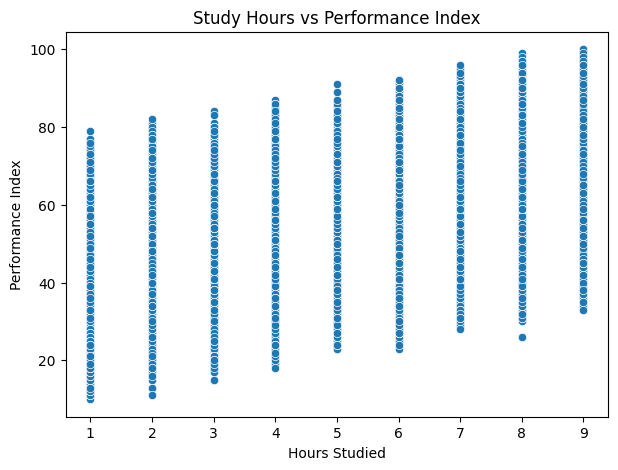

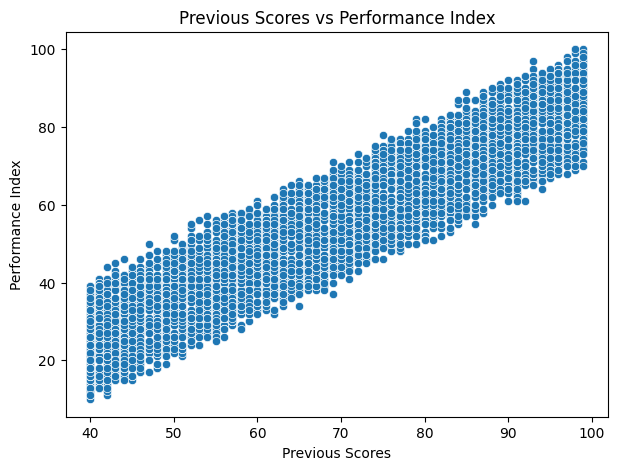

In [28]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="Hours Studied", y="Performance Index", palette='Set2')
plt.title("Study Hours vs Performance Index")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="Previous Scores", y="Performance Index")
plt.title("Previous Scores vs Performance Index")
plt.show()


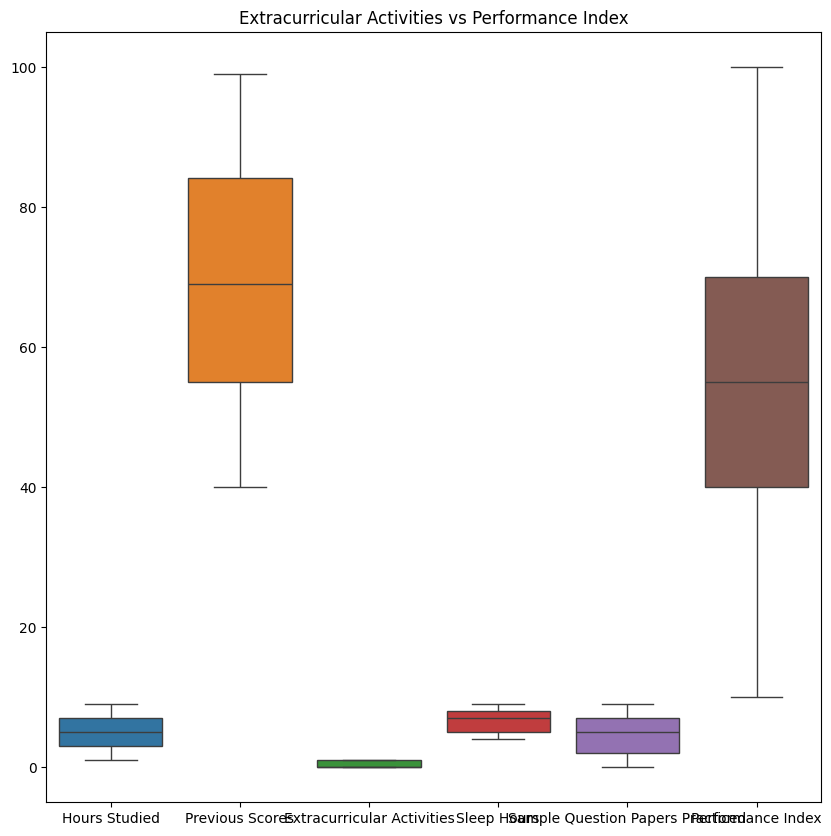

In [29]:
plt.figure(figsize=(10,10))
sns.boxplot(data)
plt.title("Extracurricular Activities vs Performance Index")
plt.show()


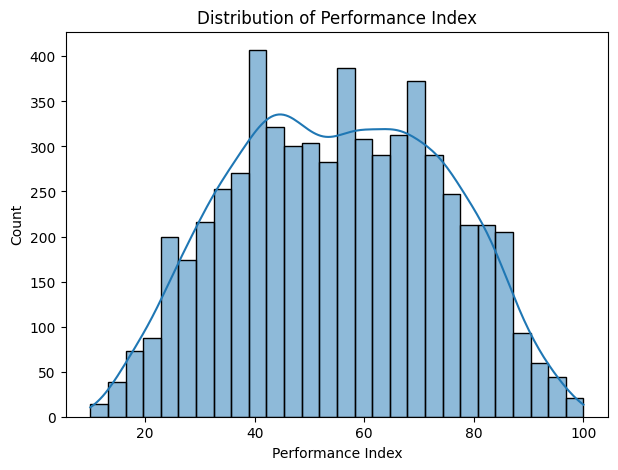

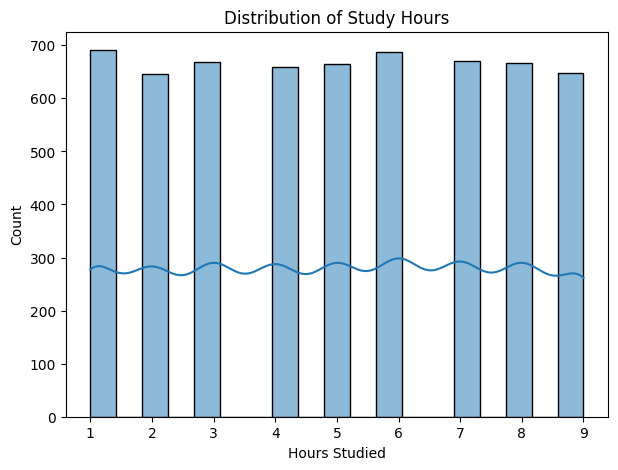

In [30]:
plt.figure(figsize=(7,5))
sns.histplot(data["Performance Index"], kde=True)
plt.title("Distribution of Performance Index")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(data["Hours Studied"], kde=True)
plt.title("Distribution of Study Hours")
plt.show()


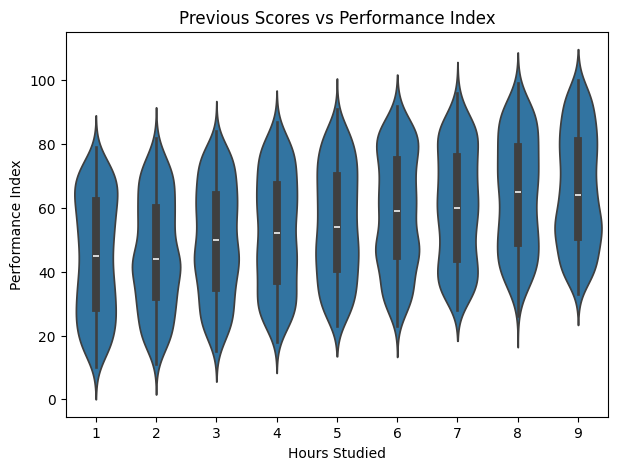

In [31]:
plt.figure(figsize=(7,5))
sns.violinplot(data=data, x="Hours Studied", y="Performance Index")
plt.title("Previous Scores vs Performance Index")
plt.show()


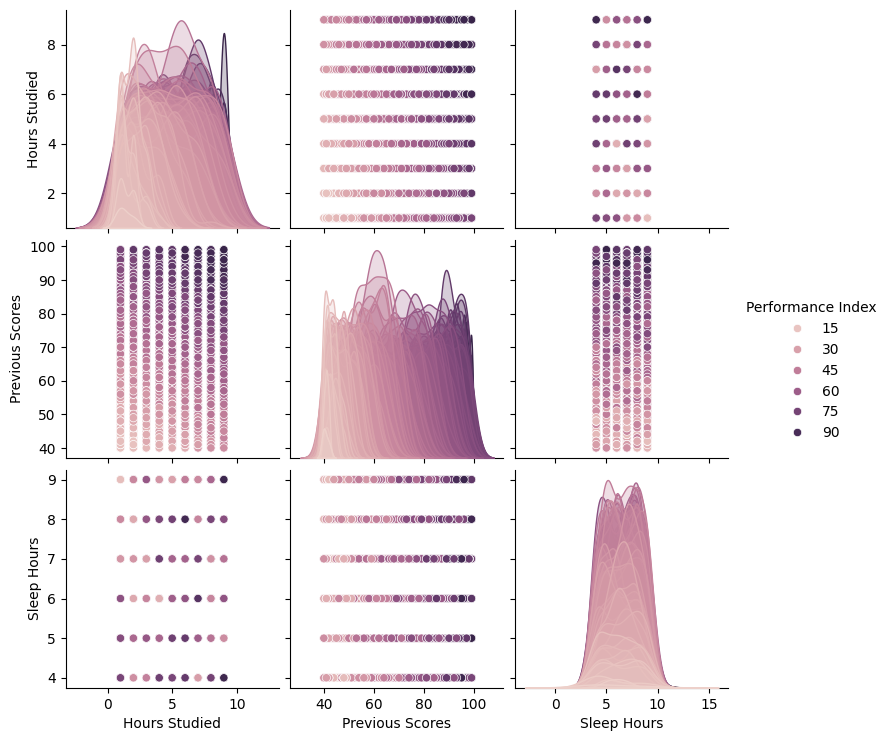

In [32]:
sns.pairplot(
    data[["Hours Studied", "Previous Scores", "Sleep Hours", "Performance Index"]],
    diag_kind="kde",
    hue="Performance Index"
)
plt.show()


## OUTLIER REMOVAL

In [33]:
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols.remove(target_col)

Q1 = data[numeric_cols + [target_col]].quantile(0.25)
Q3 = data[numeric_cols + [target_col]].quantile(0.75)
IQR = Q3 - Q1

mask = ~(
    (data[numeric_cols + [target_col]] < (Q1 - 1.5 * IQR)) |
    (data[numeric_cols + [target_col]] > (Q3 + 1.5 * IQR))
).any(axis=1)

data = data[mask]

## SPLIT DATA

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X = data.drop(columns=target_col)
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## SCALING

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Linear Regression

In [38]:
from sklearn.metrics import r2_score

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("Linear Regression")
print("Train R²:", train_r2)
print("Test R²:", test_r2)

Linear Regression
Train R²: 0.9887884394465746
Test R²: 0.9886195214069481


## Decision Tree Regressor

In [40]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42, max_depth=5)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("Decision Tree")
print("Train R²:", train_r2)
print("Test R²:", test_r2)


Decision Tree
Train R²: 0.964160171145689
Test R²: 0.9619520957048765


## Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("Random Forest")
print("Train R²:", train_r2)
print("Test R²:", test_r2)


Random Forest
Train R²: 0.9841805040361071
Test R²: 0.9823777295524909


## K-Nearest Neighbors Regressor

In [42]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=7)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("KNN")
print("Train R²:", train_r2)
print("Test R²:", test_r2)


KNN
Train R²: 0.9798377837391409
Test R²: 0.9715456327382819


## Support Vector Regressor (SVM)

In [43]:
from sklearn.svm import SVR

model = SVR(kernel="rbf", C=10, epsilon=0.1)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("SVR")
print("Train R²:", train_r2)
print("Test R²:", test_r2)


SVR
Train R²: 0.9886320606127723
Test R²: 0.9874590234312313


In [44]:
model = SVR(kernel="sigmoid")
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("SVR")
print("Train R²:", train_r2)
print("Test R²:", test_r2)

SVR
Train R²: -3.196990310151687
Test R²: -2.9540026885819093


In [45]:
model = SVR(kernel="linear", C=10, epsilon=0.1)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("SVR")
print("Train R²:", train_r2)
print("Test R²:", test_r2)

SVR
Train R²: 0.9887857584590242
Test R²: 0.9886200949101753


In [46]:
model = SVR(kernel="poly", C=10, epsilon=0.1)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("SVR")
print("Train R²:", train_r2)
print("Test R²:", test_r2)

SVR
Train R²: 0.9863996706676404
Test R²: 0.9860335962954433


## AdaBoost Regressor

In [47]:
from sklearn.ensemble import AdaBoostRegressor

model = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.01,
    random_state=42
)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("AdaBoost")
print("Train R²:", train_r2)
print("Test R²:", test_r2)


AdaBoost
Train R²: 0.9147466358771742
Test R²: 0.9176092114919208


## Gradient Boosting Regressor

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("Gradient Boosting")
print("Train R²:", train_r2)
print("Test R²:", test_r2)


Gradient Boosting
Train R²: 0.9894960235686975
Test R²: 0.9879689423753436


## XGBoost Regressor

In [49]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print("XGBoost")
print("Train R²:", train_r2)
print("Test R²:", test_r2)


XGBoost
Train R²: 0.9900187097614803
Test R²: 0.987830264812616


## CROSS VALIDATION - KFOLD AND GRID SEARCH

In [57]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=42)
}

print("\nMODEL PERFORMANCE\n" + "-" * 40)

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    results[name] = test_r2
    print(f"{name}: Train R² = {train_r2:.3f}, Test R² = {test_r2:.3f}")


MODEL PERFORMANCE
----------------------------------------
Linear Regression: Train R² = 0.989, Test R² = 0.989
Decision Tree: Train R² = 1.000, Test R² = 0.974
Random Forest: Train R² = 0.998, Test R² = 0.985
KNN: Train R² = 0.981, Test R² = 0.970
SVM: Train R² = 0.983, Test R² = 0.982
AdaBoost: Train R² = 0.977, Test R² = 0.977
Gradient Boosting: Train R² = 0.989, Test R² = 0.988
XGBoost: Train R² = 0.995, Test R² = 0.985


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X, y, cv=kf, scoring="r2")

print("Mean CV R²:", scores.mean())


Best Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)
Mean CV R²: 0.9880919634755347


In [52]:
from sklearn.model_selection import GridSearchCV

In [53]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

In [54]:
grid = GridSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [55]:
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_score = r2_score(y_test, best_model.predict(X_test))

In [ ]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
print("\nBEST MODEL AFTER GRID SEARCH")
print(best_model)
print(f"\nBEST TEST R² SCORE: {best_score:.3f}")


BEST MODEL AFTER GRID SEARCH
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

BEST TEST R² SCORE: 0.988


In [ ]:
feature_columns = X.columns.tolist()


In [ ]:
manual_input = {}

manual_input["Hours Studied"] = float(input("Enter Study Hours per day: "))
manual_input["Previous Scores"] = float(input("Enter Previous Scores: "))
manual_input["Sleep Hours"] = float(input("Enter Sleep Hours: "))
manual_input["Extracurricular Activities"] = int(input("Extracurricular Activities (0 = No, 1 = Yes): "))
manual_input["Sample Question Papers Practiced"] = int(input("Number of sample papers practiced: "))

input_df = pd.DataFrame([manual_input])
input_df = input_df.reindex(columns=feature_columns, fill_value=0)

input_scaled = scaler.transform(input_df)
prediction = best_model.predict(input_scaled)

print("\nPredicted Performance Index:", round(prediction[0], 2))


Predicted Performance Index: 92.58


In [ ]:
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
5995,8,46,1,6,3,41.0
5996,3,61,0,6,3,41.0
5997,9,96,1,9,1,94.0
5998,6,89,1,4,5,80.0


In [ ]:
import joblib

joblib.dump(best_model, "performance_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "features.pkl")

['features.pkl']